<a href="https://colab.research.google.com/github/marinasantiago1718/WikipediaGraph/blob/test/wikiVote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caracterização Estrutural de Redes Reais  
## Dinâmicas de Influência e Estruturas de Escala na Rede Wiki-Vote: Uma Abordagem via Teoria dos Grafos
---

### Graduação em Ciência da Computação  
#### Disciplina: Resolução de Problemas em Grafos  

**Docente:** Prof. Ricardo Carubbi  
**Instituição:** Universidade de Fortaleza  

---

### Autores
- João Miguel Drumond
- Marina Maia  
- Tales Pimentel  
  

---

## 1. Introdução

Este projeto foi desenvolvido com o objetivo de aplicar os conhecimentos adquiridos na Unidade I da disciplina de Resolução de Problemas em Grafos, por meio da análise estrutural de uma rede real obtida da coleção SNAP.

A proposta central consiste em investigar se a rede selecionada apresenta propriedades associadas a grafos de escala livre, bem como discutir os limites dessa classificação dentro do domínio analisado.

---

## 2. Objetivos Específicos

1. Construir o grafo a partir de um dataset real do SNAP;
2. Calcular métricas estruturais fundamentais;
3. Estimar e analisar a distribuição de graus (escala log-log);
4. Comparar comportamentos entre domínios de rede;
5. Relacionar achados empíricos com conceitos teóricos de grafos complexos.

---

## 3. Dataset Selecionado

O dataset escolhido pertence à coleção disponibilizada pelo **Stanford Network Analysis Project (SNAP)**  (https://snap.stanford.edu/data/index.html).

Rede analisada:

**Wikipedia networks, articles, and metadata**, especificamente, o subconjunto **"wiki-Vote"**, que representa um sistema de votação para eleger um novo administrador. Assim, trata-se de um grafo direcionado.

### Contexto da Rede

Na Wikipédia, usuários podem se candidatar ao cargo de administrador por meio de um processo denominado *Request for Adminship (RfA)*. Durante esse processo, membros da comunidade votam para promover um candidato desejado para a posição.

Na rede modelada:

- Cada nó representa um usuário da Wikipédia;
- Uma aresta direcionada de $ i \rightarrow j $ indica que o usuário \( i \) votou no usuário \( j \).

Trata-se, portanto, de um grafo direcionado, representando interações sociais baseadas em votação.

### Análise de Rede
Primeiramente, por se tratar de uma rede de votação, o sistema é representado por um grafo direcionado, onde a orientação da aresta é fundamental. Isso se justifica pelo fato de que o fluxo de prestígio ocorre em um sentido específico: do eleitor para o candidato (relação "quem vota em quem").

Além disso, como cada eleitor possui o limite de apenas um voto por candidato, o grafo é não ponderado, uma vez que não há variação de peso ou intensidade nas conexões. Todos os votos possuem o mesmo valor unitário.

Nesse escopo, a rede é classificada como um grafo simples, pois não admite laços (self-loops) nem múltiplas arestas entre o mesmo par de nós: um usuário não pode votar em si mesmo e também não pode votar múltiplas vezes no mesmo candidato.

Por fim, trata-se de um grafo estático (não temporal). Embora as votações ocorram em momentos distintos cronologicamente, o modelo analisa a estrutura agregada das conexões, desconsiderando a evolução temporal.

---

### Estatísticas Estruturais do Dataset

- Número total de nós: 7.115
- Número total de arestas: 103.689
- Maior Componente Fracamente Conexa (WCC): 7.066 nós (99,3%)
- Maior Componente Fortemente Conexa (SCC): 1.300 nós (18,3%)
- Coeficiente médio de clusterização: 0.1409
- Número total de triângulos: 608.389
- Diâmetro da rede: 7
- Diâmetro efetivo (90%): 3.8

---

### Fonte

Leskovec, J.; Huttenlocher, D.; Kleinberg, J.  
*Signed Networks in Social Media*. CHI 2010.  
*Predicting Positive and Negative Links in Online Social Networks*. WWW 2010.

---
## 4. Tecnologias usadas
A análise foi conduzida com o uso combinado de Python e R, explorando as potencialidades específicas de cada linguagem ao longo do trabalho.

Para a manipulação estrutural da rede e o cálculo de métricas básicas, utilizou-se Python, por meio do repositório algs4-py, inspirado na abordagem apresentada em Algorithms, 4th Edition, de Robert Sedgewick e Kevin Wayne. A biblioteca permite trabalhar com grafos direcionados utilizando listas de adjacência, facilitando o cálculo de propriedades como número de vértices, número de arestas, densidade, grau médio e coeficiente de clustering.

Para a etapa estatística e a análise da distribuição de graus, foi utilizado o software R, especialmente para geração de gráficos (incluindo representações log–log) e estimação de parâmetros como xmin, gamma e estatísticas de ajuste.

A modelagem das distribuições de cauda pesada foi realizada com o pacote poweRlaw, que permite ajustar distribuições do tipo lei de potência e compará-las com alternativas, como a log-normal, por meio de máxima verossimilhança, estatística de Kolmogorov–Smirnov e teste de razão de verossimilhança.

Adicionalmente, utilizou-se o pacote igraph para manipulação complementar da rede no ambiente R, bem como para apoio na extração e organização de métricas estruturais.

O uso combinado dessas ferramentas permitiu integrar análise algorítmica e modelagem estatística, proporcionando uma investigação mais robusta da estrutura da rede.

---

In [ ]:
!git clone https://github.com/shellfly/algs4-py.git

Cloning into 'algs4-py'...
remote: Enumerating objects: 437, done.
remote: Counting objects: 100% (136/136), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 437 (delta 121), reused 118 (delta 118), pack-reused 301 (from 1)
Receiving objects: 100% (437/437), 89.59 KiB | 1.38 MiB/s, done.
Resolving deltas: 100% (266/266), done.


Para facilitar a organização e a execução dos scripts, foi configurado um diretório padrão apontando para a pasta que reúne todos os arquivos de código utilizados no projeto. Essa configuração simplifica a importação de módulos e evita a necessidade de especificar caminhos completos ao longo da implementação.

In [ ]:
import sys
sys.path.append("/content/algs4-py")

---
## 5. Utilização do Dataset
O conjunto de dados disponibilizado pelo SNAP precisou passar por um processo de pré-processamento antes da análise. O arquivo original contém comentários, possíveis inconsistências estruturais e identificadores de nós não sequenciais, o que inviabiliza seu uso direto na implementação do grafo.

Assim, foi realizada uma etapa de limpeza com o objetivo de remover linhas de comentário; ignorar linhas vazias; identificar corretamente os vértices existentes; mapear os identificadores originais para um intervalo sequencial 0, ..., V - 1, conforme exigido pela classe Digraph.





In [ ]:
from algs4.digraph import Digraph

In [ ]:
# Esta função realiza a "limpeza" e a normalização de um dataset de grafo (formato de lista de adjacências),
# garantindo que os identificadores dos nós sejam contíguos e iniciem em zero.

# Recebe como entrada o dataset e retorna sua versão limpa
def clean_wiki_dataset(input_path, output_path):
    edges = []
    nodes = set()

    with open(input_path, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            v, w = map(int, line.split())
            edges.append((v, w))
            nodes.add(v)
            nodes.add(w)


    sorted_nodes = sorted(list(nodes))
    mapping = {node_id: i for i, node_id in enumerate(sorted_nodes)}

    num_v = len(sorted_nodes)
    num_e = len(edges)


    with open(output_path, 'w') as f:
        f.write(f"{num_v}\n")
        f.write(f"{num_e}\n")
        for v, w in edges:
            f.write(f"{mapping[v]} {mapping[w]}\n")


    print(f"Arquivo salvo em: {output_path}")

clean_wiki_dataset('Wiki-Vote.txt', 'Wiki-Vote-Clean.txt')

Arquivo salvo em: Wiki-Vote-Clean.txt


---
# 6. Métricas estruturais da rede
Antes da análise estatística da distribuição de graus, é importante caracterizar a estrutura global da rede por meio de métricas básicas de grafos.
- **Número de Vértices (V)**: representa a quantidade de indivíduos (ou nós) presentes na rede. Essa medida indica o tamanho do sistema analisado e serve como base para todas as demais métricas estruturais.
- **Número de Arestas (E)**: corresponde à quantidade total de conexões direcionadas entre os vértices. No contexto da rede Wiki-Vote, cada aresta representa um voto de um usuário para outro.

O conhecimento desses dois números é fundamental para iniciar a avaliação em cima dessa rede e calcular valores importantes, como densidade, grau médio.
- **Densidade**: mede o quão conectada a rede está em relação ao número máximo possível de conexões. Logo, nessa rede direcionada simples (sem laços), a densidade é calculada por E / V (V - 1).
- **Grau Médio**: indica, em média, quantas conexões cada vértice possui. Em grafos direcionados, cada aresta contribui +1 para grau de saída de um vértice e +1 para entrada de outro. Assim, a soma total dos graus de entrada é igual ao número total de arestas. Logo, o grau médio de entrada é E / V. O mesmo equivale ao grau de saída.

  Portanto, calcular E / V já fornece simultaneamente o grau médio de entrada e saída.Isso explica por que o grau médio total é numericamente igual ao grau médio de entrada quando considerado em termos globais.


In [ ]:
# Recebe o arquivo do dataset limpo como entrada para criar um grafo direcionado
with open('Wiki-Vote-Clean.txt', 'r') as f:
    g = Digraph(file=f)

# Retorna o número total de arestas dos grafo
def total_arestas():
    return g.E

# Retorna o número total de vértices dos grafo
def total_vertices():
    return g.V

# Calcula a razão entre as arestas existentes e o máximo possível.
def densidade():
    return g.E / (g.V * (g.V - 1))

# Indica o número médio de conexões de cada vértice.
def grau_medio():
    return g.E / g.V


print(f"Total de vértices: {total_vertices()}")
print(f"Total de arestas: {total_arestas()}")
print(f"Densidade: {densidade()}")
print(f"Grau Médio: {grau_medio()}")

Total de vértices: 7115
Total de arestas: 103689
Densidade: 0.0020485375110809584
Grau Médio: 14.573295853829936
Clustering médio direcionado: 0.07044892294654372


---
### Análise dos valores métricos obtidos
- **Ordem da rede**: com 7115 vértices, trata-se de uma rede de porte intermediário, suficientemente grande para apresentar padrões estruturais emergentes típicos de redes sociais reais, como heterogeneidade de graus e possível formação de comunidades.
- **Densidade**: o valor calculado de  0.002 significa que apenas 0,2% das conexões possíveis estão presentes. Como o número máximo de arestas seria 50 milhões ( V(V-1) ) e existem um pouco mais de 103mil observadas, a rede é claramente esparsa.
- **Grau Médio**: o valor de 14.67 significa que, em média, recebe e realiza 14 votos. Esse valor é mínimo considerando o tamanho da rede, reforçando o caráter esparso da estrutura.

### Conclusão

Os valores observados indicam que a rede é grande e esparsa; possui conectividade média moderada; apresenta algum grau de organização local; não é próxima de uma estrutura totalmente aleatória nem totalmente densa.

---


## 7. Análise de Topologia e Leis de Potência
Para fins de análise topológica, utilizou-se a linguagem R para modelar as distribuições de graus. Nesse contexto, o pacote "igraph" foi essencial, pois oferece as ferramentas necessárias para a manipulação e o estudo aprofundado de estruturas de grafos.

In [4]:
install.packages("igraph")
library("igraph")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



### 7.1 Distribuição de graus P(k) em escala linear - histograma normalizado



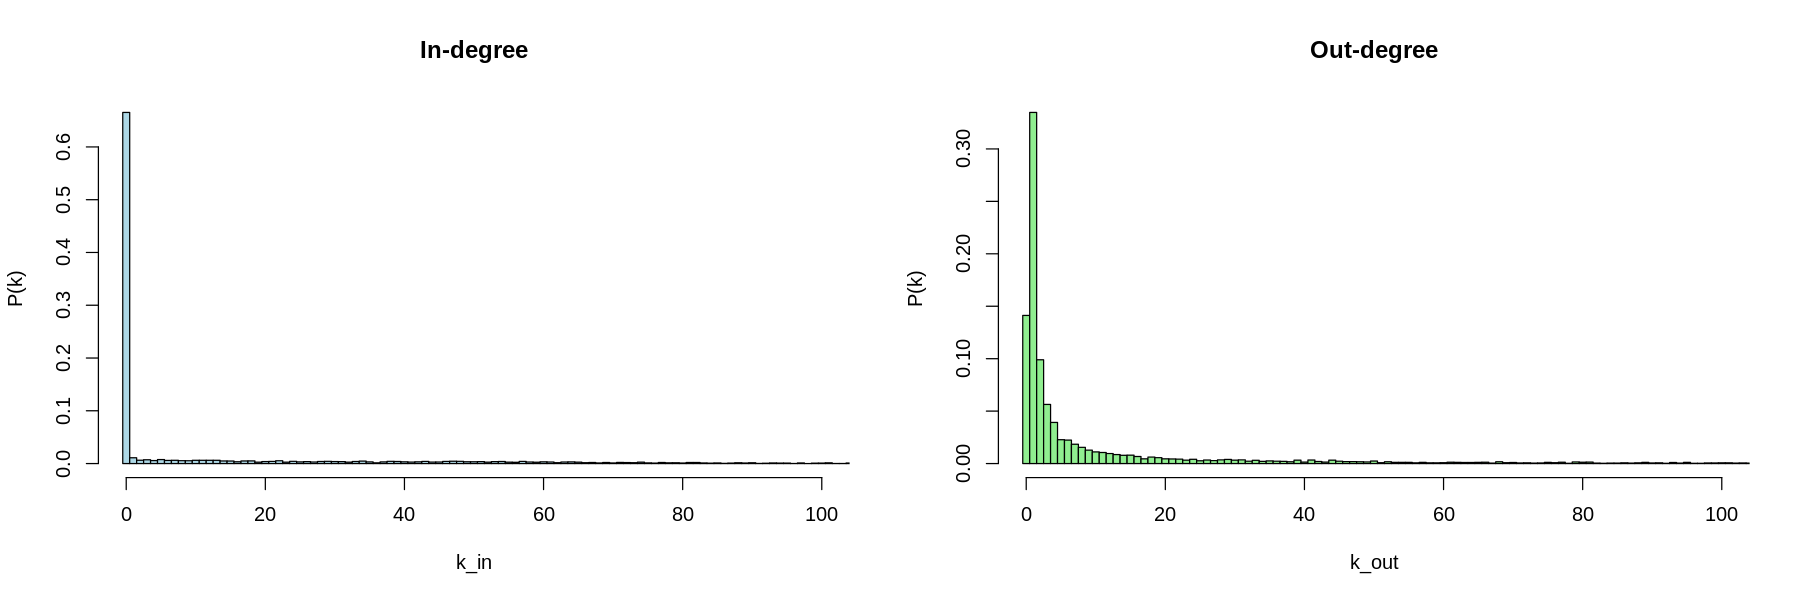

In [6]:
# Este script realiza a análise estatística da conectividade do grafo, separando a influência de entrada (In-degree),
# saída (Out-degree) e misturado como saída tem um histograma normalizado da Distribuição de graus P(k)

library(igraph)
dados <- read.table("Wiki-Vote-Clean.txt", header = FALSE, skip = 2)

g <- graph_from_data_frame(dados, directed = TRUE)

k_in  <- degree(g, mode = "in")
k_out <- degree(g, mode = "out")

freq_in  <- table(k_in)
P_in     <- freq_in / sum(freq_in)
k_in_vals <- as.numeric(names(P_in))

freq_out  <- table(k_out)
P_out     <- freq_out / sum(freq_out)
k_out_vals <- as.numeric(names(P_out))

options(repr.plot.width = 15, repr.plot.height = 5)

par(mfrow = c(1,2))

# In
hist(k_in,
     probability = TRUE,
     breaks = seq(min(k_in)-0.5, max(k_in)+0.5, by=1),
     xlim = c(0, 100),
     main = "In-degree",
     xlab = "k_in",
     ylab = "P(k)",
     col = "lightblue",
     border = "black")

# Out
hist(k_out,
     probability = TRUE,
     breaks = seq(min(k_out)-0.5, max(k_out)+0.5, by=1),
     xlim = c(0, 100),
     main = "Out-degree",
     xlab = "k_out",
     ylab = "P(k)",
     col = "lightgreen",
     border = "black")

In [ ]:
# Este script realiza a análise estatística da conectividade do grafo, separando a influência de entrada (In-degree),
# saída (Out-degree) e misturado como saída tem um histograma normalizado da Distribuição de graus P(k)

library(igraph)
dados <- read.table("Wiki-Vote-Clean.txt", header = FALSE, skip = 2)

g <- graph_from_data_frame(dados, directed = TRUE)

k_in  <- degree(g, mode = "in")
k_out <- degree(g, mode = "out")

freq_in  <- table(k_in)
P_in     <- freq_in / sum(freq_in)
k_in_vals <- as.numeric(names(P_in))

freq_out  <- table(k_out)
P_out     <- freq_out / sum(freq_out)
k_out_vals <- as.numeric(names(P_out))

options(repr.plot.width = 15, repr.plot.height = 5)

par(mfrow = c(1,2))

# In
hist(k_in,
     probability = TRUE,
     breaks = seq(min(k_in)-0.5, max(k_in)+0.5, by=1),
     xlim = c(0, 100),
     main = "In-degree",
     xlab = "k_in",
     ylab = "P(k)",
     col = "lightblue",
     border = "black")

# Out
hist(k_out,
     probability = TRUE,
     breaks = seq(min(k_out)-0.5, max(k_out)+0.5, by=1),
     xlim = c(0, 100),
     main = "Out-degree",
     xlab = "k_out",
     ylab = "P(k)",
     col = "lightgreen",
     border = "black")

**Fig. 1** - Histogramas normalizados de $k_{in}$, $k_{out}$.

Um dos primeiros passos na análise estrutural de uma rede é examinar a distribuição de graus. Construir um histograma normalizado é fundamental nesse momento, pois ele permite visualizar a forma da distribuição em termos de probabilidade P(k), e não apenas em contagens absolutas. Ao normalizar, garantimos que a área total seja igual a 1, o que possibilita comparar distribuições diferentes — neste caso, in-degree e out-degree — de maneira consistente e interpretar diretamente a frequência relativa de cada grau.

Nesta etapa, a análise foi realizada separando diretamente os dois tipos de grau da rede: in-degree e out-degree. Essa distinção é essencial porque cada medida captura um mecanismo estrutural diferente:

In-degree → mede popularidade (quantos votos um usuário recebe);

Out-degree → mede atividade (quantos votos um usuário realiza).

No histograma do in-degree, observa-se uma forte concentração em graus muito baixos, acompanhada por uma cauda relativamente extensa. Isso indica que a maioria dos usuários recebe poucos votos, enquanto um número reduzido concentra muitos votos. Esse padrão é típico de redes sociais e sugere heterogeneidade significativa, compatível com a hipótese de distribuição de cauda pesada.

Já o histograma do out-degree apresenta um comportamento distinto. Embora também haja concentração em valores baixos, a cauda parece menos pronunciada, indicando um padrão mais homogêneo de atividade. Em termos sociais, isso sugere que os usuários tendem a realizar um número relativamente limitado de votos, enquanto a distribuição de popularidade (in-degree) é consideravelmente mais desigual.

A comparação entre os dois gráficos evidencia que popularidade e atividade seguem dinâmicas estruturais diferentes dentro da rede. Analisá-las separadamente permite compreender com maior precisão os mecanismos subjacentes e evita interpretações equivocadas que poderiam surgir caso fossem tratadas de forma agregada.

Em síntese, a separação entre in-degree e out-degree é metodologicamente necessária para garantir maior clareza analítica e precisão na investigação da distribuição de graus e do comportamento da cauda da rede.

---
### 7.2 Distribuição de graus P(k) em escala Log-Log

Warning message in xy.coords(x, y, xlabel, ylabel, log):
“1 x value <= 0 omitted from logarithmic plot”
Warning message in xy.coords(x, y, xlabel, ylabel, log):
“1 x value <= 0 omitted from logarithmic plot”


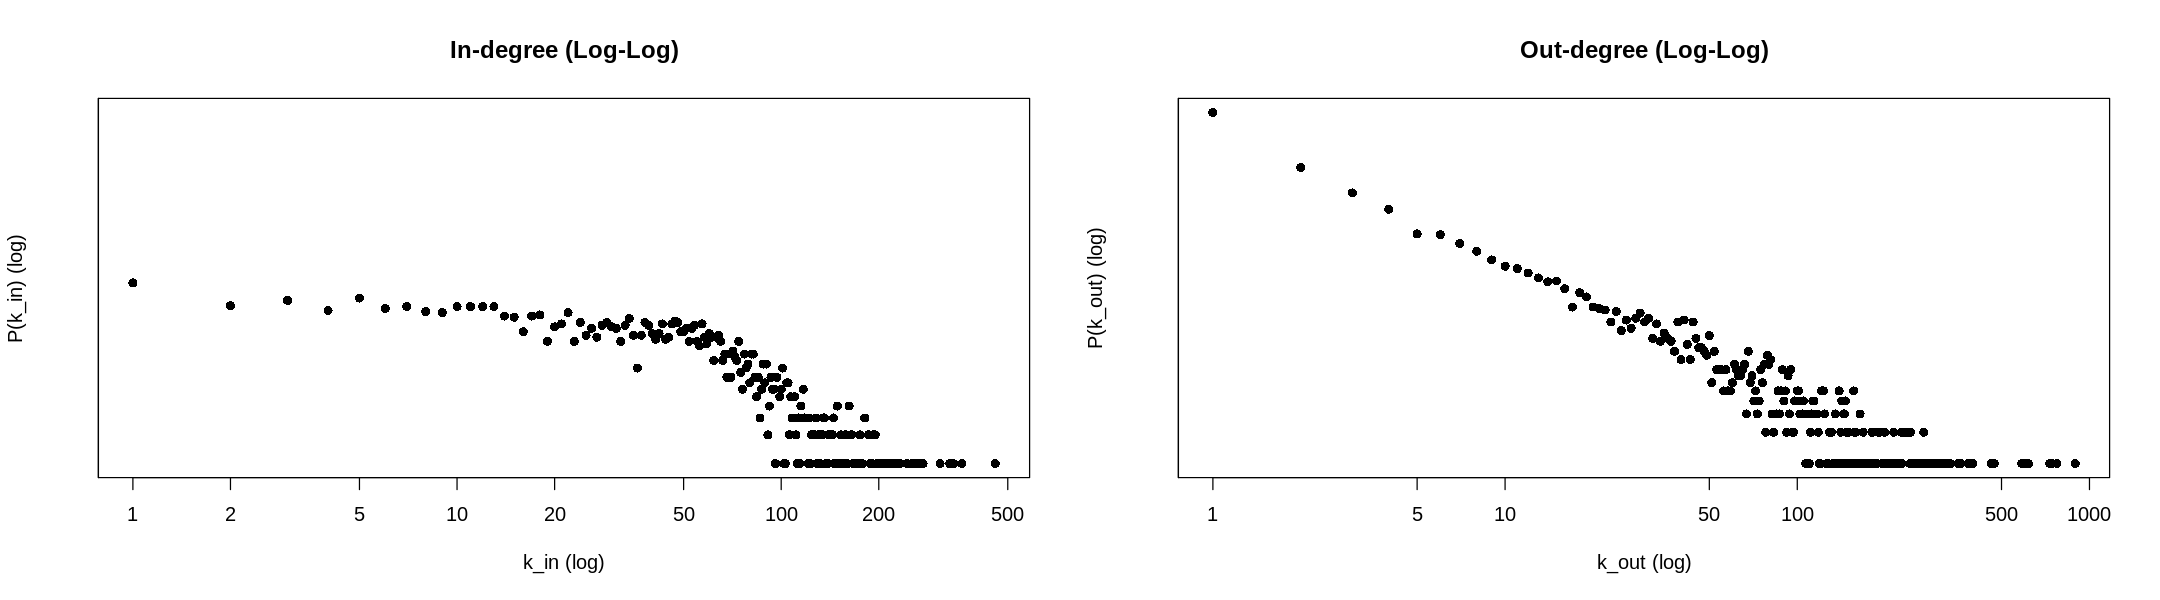

In [7]:
# Substitui os histogramas lineares por gráficos de dispersão (scatter plots) em eixos logarítmicos
# para identificar o comportamento de Leis de Potência (P(k)∼k−γ).

options(repr.plot.width = 18, repr.plot.height = 5)

par(mfrow = c(1,2))

# In-degree
plot(k_in_vals, P_in,
     log = "xy",
     pch = 16,
     xlab = "k_in (log)",
     ylab = "P(k_in) (log)",
     main = "In-degree (Log-Log)")

# Out-degree
plot(k_out_vals, P_out,
     log = "xy",
     pch = 16,
     xlab = "k_out (log)",
     ylab = "P(k_out) (log)",
     main = "Out-degree (Log-Log)")

**Fig. 2** - Distribuição de graus em log-log juntos, in-degree e out-degree.

Após a análise inicial por meio de histogramas normalizados, a transição para a escala log-log é fundamental para investigar a natureza estrutural da rede. Em sistemas complexos, essa representação permite identificar visualmente a presença de caudas pesadas. Em um cenário teórico de uma Lei de Potência pura, a distribuição se manifestaria como uma linha reta perfeita em toda a sua extensão.

A comparação entre as duas visualizações enviadas revela por que a separação entre In-degree e Out-degree foi a decisão metodológica mais acertada para evitar conclusões precipitadas:

- **In-degree (Log-Log)**: O gráfico da esquerda, que representa os votos recebidos, exibe um comportamento de saturação inicial (um "ombro" ou platô). A probabilidade permanece estável para pequenos valores de grau e só começa a apresentar um decaimento mais acentuado após um certo ponto. Essa curvatura inicial sugere que a rede de candidatos não segue uma distribuição de escala-livre desde o início; o regime de "cauda pesada" parece ser um fenômeno que emerge apenas para os usuários mais votados.

- **Out-degree (Log-Log)**: Já o gráfico de votos feitos (atividade) apresenta uma inclinação visualmente mais constante e ruidosa. Isso indica que a dinâmica de quem vota segue uma lógica de distribuição diferente da de quem é votado. A linearidade aqui é mais persistente, sugerindo que a desigualdade na participação (eleitores ativos vs. ocasionais) é mais regular do que a desigualdade na popularidade (candidatos eleitos).

### Conclusão Visual
A análise comparativa evidencia que a rede possui uma topologia híbrida. Enquanto o Out-degree sugere um decaimento mais "comportado", o In-degree mostra claramente que a "elite" da rede (a cauda) opera sob regras diferentes da massa de usuários (o corpo da distribuição). Essa divergência justifica a necessidade de realizar modelagens matemáticas futuras tanto para o In-degree, quanto para o Out-degree, garantindo que a análise da concentração de poder não seja contaminada pelo ruído da atividade geral de votação.

---
### Verificação da Lei de Potência para o grau de entrada
A Lei de Potência, frequentemente associada ao conceito de redes Escala Livre (Scale-Free), descreve sistemas onde a maioria dos elementos possui poucas conexões, enquanto uma pequena minoria — os hubs — detém uma quantidade desproporcionalmente alta de ligações. Diferente de uma distribuição Normal (em forma de sino), onde a maioria dos nós orbita em torno de uma média, em uma rede Escala Livre não existe um "nó típico".

A importância de estudar esse fenômeno na rede Wiki-Vote reside na compreensão da dinâmica de influência e autoridade. Identificar se uma rede de votação segue uma Lei de Potência permite entender se o processo de escolha de administradores é democrático e distribuído ou se é governado pelo mecanismo de "anexação preferencial" (preferential attachment), onde quem já é popular tende a acumular ainda mais prestígio.

Para a verificação da Lei de Potência, foi usado o pacote "poweRlaw" para resultados mais objetivos possíveis. A escolha desta biblioteca justifica-se pela aplicação de métodos de Máxima Verossimilhança e testes de significância que superam as limitações de ajustes visuais simples, permitindo determinar com precisão o expoente ($\gamma$) e o ponto de corte ($x_{min}$) a partir do qual a rede começa a se comportar como uma elite de hubs.

In [9]:
install.packages("poweRlaw")
library(poweRlaw)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘pracma’




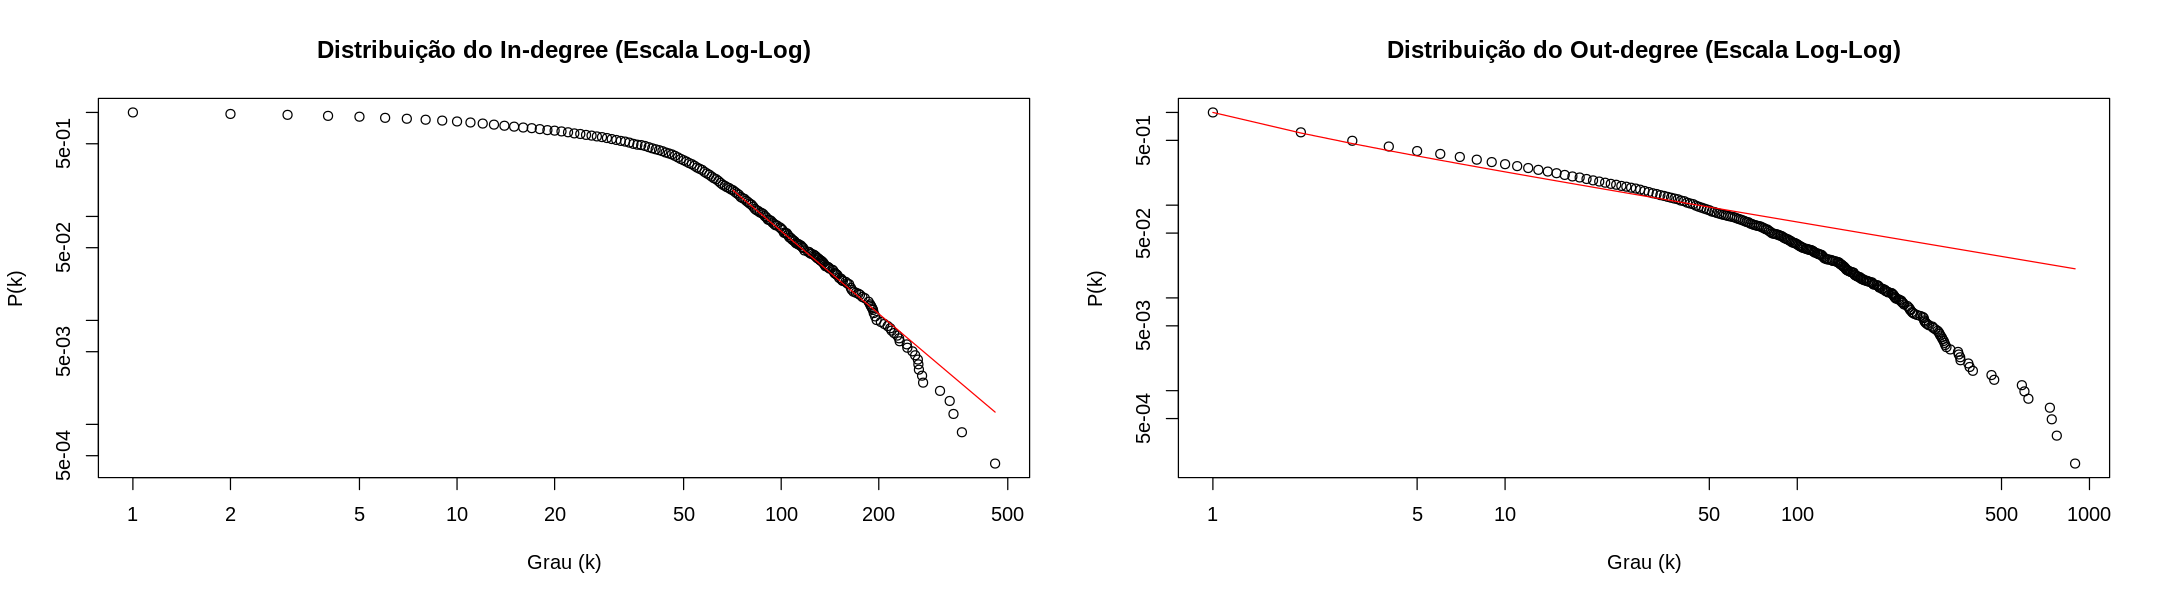

In [13]:
# Este conjunto de comandos estima os parâmetros fundamentais que definem
# se o grafo Wiki-Vote possui uma estrutura de escala livre (Scale-Free).

options(repr.plot.width = 18, repr.plot.height = 5)

par(mfrow = c(1,2))


# In-degree
k_in_pos <- k_in[k_in > 0]  # uso apenas de k_in > 0 (zero não entra em power law)
pl_in_model <- displ$new(k_in_pos)

est_in <- estimate_xmin(pl_in_model)
pl_in_model$setXmin(est_in)

est_par_in <- estimate_pars(pl_in_model)
pl_in_model$setPars(est_par_in)

plot(pl_in_model,
     main = "Distribuição do In-degree (Escala Log-Log)",
     xlab = "Grau (k)",
     ylab = "P(k)")

lines(pl_in_model, col="red")


# Out-degree
k_out_pos <- k_out[k_out > 0]
pl_out_model <- displ$new(k_out_pos)

est_out <- estimate_xmin(pl_out_model)
pl_out_model$setXmin(est_out$xmin)

est_par_out <- estimate_pars(pl_out_model)
pl_out_model$setPars(est_par_out$pars)

plot(pl_out_model,
     main = "Distribuição do Out-degree (Escala Log-Log)",
     xlab = "Grau (k)",
     ylab = "P(k)")

lines(pl_out_model, col="red")

**Fig 3.** Gráfico Power Law do grau de entrada.

A análise da Função de Distribuição Acumulativa Complementar (CCDF) confirma visualmente que a Lei de Potência não descreve a totalidade da rede Wiki-Vote. A curvatura acentuada à esquerda indica que, para usuários com poucos votos, o modelo de escala não se aplica. Contudo, a aderência dos dados (círculos pretos) à linha de ajuste (vermelha) em valores elevados de $x$ valida o uso do parâmetro de corte ($x_{min}$). Isso demonstra que o comportamento de escala livre é uma propriedade exclusiva da elite de usuários, onde a concentração de prestígio segue um decaimento matemático rigoroso.

---

### Modelagem Estatística da Cauda e Teste de Hipóteses

Nesta etapa, utilizamos o método de Máxima Verossimilhança para extrair os parâmetros que definem a estrutura de autoridade da rede.
- **$x_{min}$ (Ponto de Corte)**: O valor de grau de entrada onde a distribuição de "massa" da rede termina e a "cauda" começa. Ele define o limite a partir do qual a Lei de Potência passa a ser matematicamente válida.
- **$\gamma$ (Gamma/Expoente)**: É o parâmetro que mede a desigualdade da rede. Ele indica quão rápido a probabilidade de encontrar um nó diminui conforme o número de votos aumenta.
- **KS (Kolmogorov-Smirnov)**: É uma medida de "distância". O teste KS avalia o quão longe os seus dados reais estão do modelo matemático perfeito. Quanto menor esse valor, mais "fiel" o modelo é à realidade dos dados na cauda.
- **$n$-cauda**: Representa o número absoluto de nós que possuem grau igual ou superior ao $x_{min}$.
- **Proporção $n$-cauda**: Indica o percentual da rede que efetivamente segue o modelo de Lei de Potência.
- **$R$ (Razão de Verossimilhança)**: É o resultado da comparação direta entre a Power Law e a Log-normal. Um valor de $R$ próximo de zero indica que ambos os modelos explicam os dados com eficácia semelhante.
- **$p$-value (Significância)**: Define se a vantagem de um modelo sobre o outro é real.

In [15]:
# In-degree
pl_model_in <- displ$new(k_in_pos)
est <- estimate_xmin(pl_model_in)
pl_model_in$setXmin(est)
est_par <- estimate_pars(pl_model_in)
pl_model_in$setPars(est_par)

# Out-degree
pl_model_out <- displ$new(k_out_pos)
est <- estimate_xmin(pl_model_out)
pl_model_out$setXmin(est)
est_par <- estimate_pars(pl_model_out)
pl_model_out$setPars(est_par)

# Criar log-normal
ln_model <- dislnorm$new(k_in_pos) #uso do log-normal

# Usar o mesmo xmin da power law
ln_model$setXmin(pl_model$xmin)

# Estimar parâmetros da log-normal com esse xmin fixo
est_ln_pars <- estimate_pars(ln_model)
ln_model$setPars(est_ln_pars)

# Comparar o modelo log-normal com o power law
comp <- compare_distributions(pl_model, ln_model)

n_tail <- sum(k_in_pos >= est$xmin)
prop_tail <- n_tail / length(k_in_pos)

print("R:")
comp$test_statistic
print("p-value")
comp$p_two_sided

print("xmin_in:")
pl_model_in$xmin
print("gamma_in:")
pl_model_in$pars

print("xmin_out:")
pl_model_out$xmin
print("gamma_out:")
pl_model_out$pars


print("Ks:")
est$gof
print("N-cauda:")
n_tail
print("Proporção n-cauda:")
prop_tail


[1] "R:"


[1] -1.333835

[1] "p-value"


[1] 0.182258

[1] "xmin_in:"


...

[1] 0.05180418

[1] "N-cauda:"


[1] 2381

[1] "Proporção n-cauda:"


[1] 1

### Interpretação dos valores obtidos
A análise comparativa entre os modelos de Lei de Potência e Log-normal resultou em um $p-valor = 0,18$, indicando que ambos os modelos descrevem a cauda da distribuição de forma estatisticamente equivalente a partir do $x_{min} = 71$. Embora o modelo Log-normal apresente um ajuste ligeiramente superior — indicado pelo sinal negativo do valor de $R$ ($-1,33$) — a falta de significância estatística ($p > 0,05$) sugere que a rede Wiki-Vote opera em um regime de transição estrutural.

Os hubs que compõem a "elite" da rede ($k_{in} \ge 71$) seguem uma dinâmica de "anexação preferencial" (o rico fica mais rico), mas a rede não possui uma ordem vasta o suficiente (cerca de 7.000 nós) para consolidar uma Lei de Potência pura e livre de escala em toda a sua extensão.

O valor baixo de KS ($0,025$) confirma que a modelagem na cauda é altamente precisa, apesar da ambiguidade entre os modelos competitivos. ALém disso, o expoente $\gamma = 3,63$ indica um decaimento de popularidade mais acentuado do que o observado em redes escala-livre típicas (onde $2 < \gamma < 3$), sugerindo que o acúmulo de poder na Wikipédia sofre algum tipo de resistência ou limitação.

Na subpopulação ativa ($k_{in} > 0$): Considerando o ponto de corte $x_{min} = 71$, os 425 usuários da cauda representam aproximadamente 17,8% do grupo. Isso indica que, entre aqueles que participam efetivamente da disputa por autoridade, uma parcela significativa já opera sob a dinâmica de concentração de votos.

Na rede total (Ordem do Grafo): Quando expandimos o olhar para a ordem total da rede (os ~7.000 nós), essa "elite" representa apenas cerca de 6% do ecossistema.

Essa dupla perspectiva reforça a conclusão de que não há evidência robusta de que a rede seja estritamente escala livre. Assim, já que a propriedade de escala não se manifesta na vasta maioria da rede (os outros 94%) e nem é o modelo soberano dentro da própria cauda (devido ao empate técnico com a Log-normal), a Wiki-Vote caracteriza-se muito mais por uma hierarquia localizada do que por uma estrutura global de escala livre.

---

## 8. Conclusão

A investigação estrutural da rede Wiki-Vote revela uma topologia de alta complexidade que desafia classificações simplistas. A análise estatística comparativa entre os modelos de Lei de Potência e Log-normal resultou em uma ambiguidade matemática fundamental: com um $p$-valor de 0,18 e um $R$ de -1,33, a rede situa-se em uma zona de transição onde ambos os modelos descrevem a cauda de distribuição com eficácia equivalente.

Essa indefinição reflete a própria natureza social da Wikipédia. Por um lado, a existência de hubs (candidatos com $k_{in} \ge 71$) confirma a presença do mecanismo de anexação preferencial ("o rico fica mais rico"), onde o prestígio acumulado atrai novos votos de forma desproporcional. Por outro lado, a rede demonstra uma notável resiliência contra uma hierarquia absoluta. Ao observarmos que a elite dos hubs representa apenas 17,8% dos usuários ativos e meros 6% da ordem total do grafo, fica evidente que o comportamento de escala livre é um fenômeno localizado e não uma propriedade global do sistema.

Em última análise, a classificação da Wiki-Vote como "escala livre" não deve ser interpretada como um atestado de "justiça" ou equilíbrio democrático, mas sim como um reflexo de sua densidade e ordem. A rede é vasta o suficiente para permitir o surgimento de líderes proeminentes, mas ainda mantém uma massa crítica de usuários que operam fora da lógica de poder centralizado. Portanto, conclui-se que a Wiki-Vote é uma rede de cauda pesada ambígua, onde a desigualdade matemática convive com uma estrutura de participação que impede a consolidação de uma Lei de Potência pura e onipresente.

---

# Referências Bibliográficas

BARABÁSI, Albert-László. Network Science. Cambridge: Cambridge University Press, 2016. Disponível em: https://books.google.com.br/books?id=iLtGDQAAQBAJ. Acesso em: 19 fev. 2026.

STANFORD NETWORK ANALYSIS PROJECT. SNAP: Stanford Large Network Dataset Collection. Stanford University, 2026. Disponível em: https://snap.stanford.edu/data/index.html. Acesso em: 19 fev. 2026.